# Import libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read the uploaded dataset

In [4]:

file_path = '../data/raw/yield_df.csv'

df = pd.read_csv(file_path)

# Display basic info and first few rows
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


# Filter rows where Area is India

In [6]:
# Filter rows where Area is India
india_df = df[df['Area'] == 'India'].copy()

# Reset index
india_df.reset_index(drop=True, inplace=True)

# Display sample
india_df.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,10502,India,Cassava,1990,205381,1083.0,75000.0,25.58
1,10503,India,Cassava,1990,205381,1083.0,75000.0,26.88
2,10504,India,Cassava,1990,205381,1083.0,75000.0,25.79
3,10505,India,Cassava,1990,205381,1083.0,75000.0,24.10
4,10506,India,Cassava,1990,205381,1083.0,75000.0,25.25


In [7]:
print("Missing values in India data:")
print(india_df.isnull().sum())

Missing values in India data:
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [8]:
numeric_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
india_df[numeric_cols] = india_df[numeric_cols].fillna(india_df[numeric_cols].mean())

In [9]:
india_df['kg_per_ha_yield'] = india_df['hg/ha_yield'] / 10

# Summary Statistics

In [11]:
print("Summary Statistics:")
india_df.describe()

Summary Statistics:


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,kg_per_ha_yield
count,4048.000000,4048.000000,4048.000000,4048.0,4048.000000,4048.000000,4048.000000
mean,12525.500000,2001.434783,80884.467391,1083.0,48459.040000,26.012589,8088.446739
std,1168.701273,7.064719,95950.224381,0.0,14997.351972,0.909861,9595.022438
min,10502.000000,1990.000000,6553.000000,1083.0,14485.330000,23.260000,655.300000
25%,11513.750000,1995.000000,13704.750000,1083.0,37423.000000,25.460000,1370.475000
50%,12525.500000,2001.000000,28124.000000,1083.0,46195.000000,25.980000,2812.400000
75%,13537.250000,2008.000000,112471.000000,1083.0,61257.000000,26.670000,11247.100000
max,14549.000000,2013.000000,385818.000000,1083.0,75000.000000,28.850000,38581.800000


# Average yield per crop

In [13]:
avg_yield_crop = india_df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

print("Average yield per crop (kg/ha):")
avg_yield_crop

Average yield per crop (kg/ha):


Item
Cassava           282234.434783
Potatoes          182060.304348
Sweet potatoes     87825.173913
Rice, paddy        30295.739130
Wheat              26546.826087
Maize              19305.913043
Soybeans           10354.913043
Sorghum             8452.434783
Name: hg/ha_yield, dtype: float64

# Average Crop Yield in India Over Years

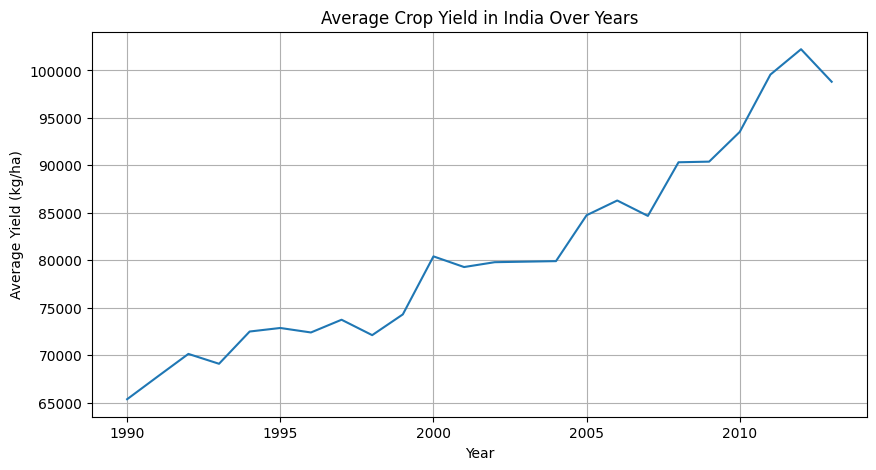

In [14]:
yearly_avg_yield = india_df.groupby('Year')['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='hg/ha_yield', data=yearly_avg_yield)
plt.title('Average Crop Yield in India Over Years')
plt.xlabel('Year')
plt.ylabel('Average Yield (kg/ha)')
plt.grid(True)
plt.show()

# Filter for Rice

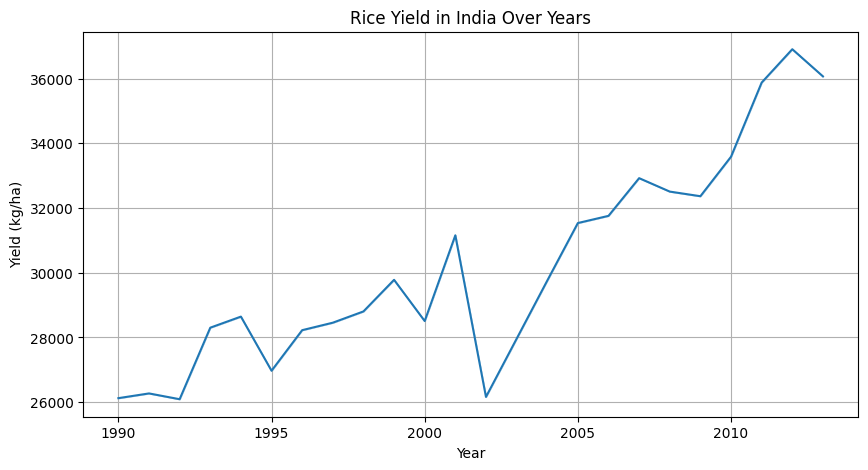

In [15]:

rice_df = india_df[india_df['Item'].str.contains('Rice', case=False)]

plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='hg/ha_yield', data=rice_df)
plt.title('Rice Yield in India Over Years')
plt.xlabel('Year')
plt.ylabel('Yield (kg/ha)')
plt.grid(True)
plt.show()


# Correlation Matrix

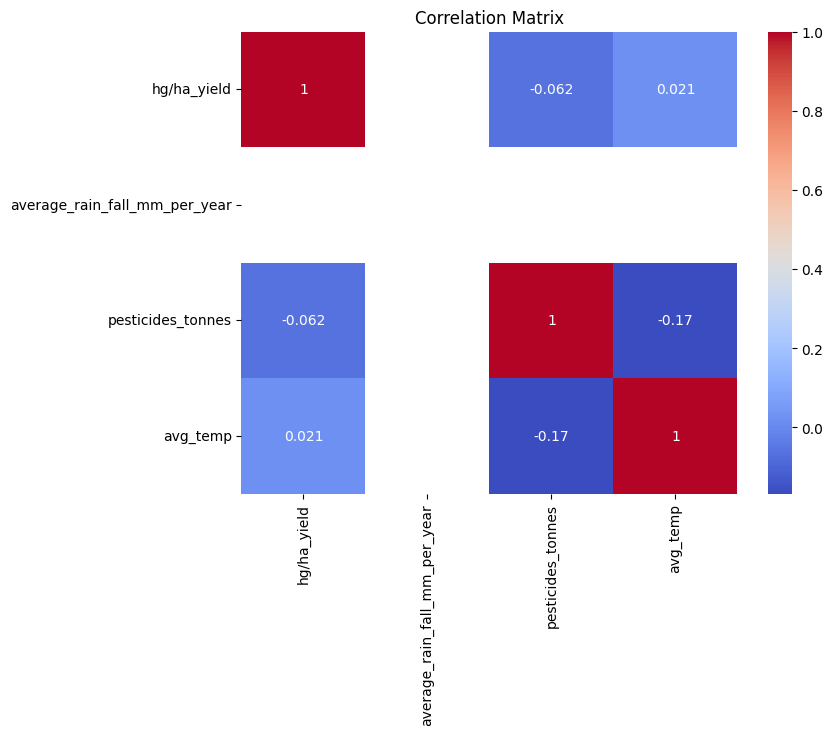

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(india_df[['hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Save cleaned and processed India-only dataset for model training

In [17]:
india_df.to_csv('../data/processed/Processed_India_Crop_Yield_Data.csv', index=False)

print("Processed India data saved as 'Processed_India_Crop_Yield_Data.csv'")

Processed India data saved as 'Processed_India_Crop_Yield_Data.csv'
